Dataset Understanding and Exploration

In [1]:
import sys
print(sys.executable)

c:\Users\maria\Documents\GitHub\NLP-project\.venv\Scripts\python.exe


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
transcript_folder = "../data/Transcripts"
qa_folder = "../data/QA"

In [4]:
transcripts = []

for file in os.listdir(transcript_folder):
    with open(os.path.join(transcript_folder, file), encoding="utf-8") as f:
        transcripts.append(f.read())

print("Number of transcripts:", len(transcripts))

Number of transcripts: 13


In [5]:
qa_data = []

for file in os.listdir(qa_folder):
    df = pd.read_csv(os.path.join(qa_folder, file))
    qa_data.append(df)

total_questions = sum(len(df) for df in qa_data)

print("Total QA pairs:", total_questions)

Total QA pairs: 3890


In [6]:
qa_data[0].head()

,video_id,video_title,question_id,question,answer,difficulty
0,0urc3PabvOs,مصير الأرض و الشمس و كل شيء | الدحيح,0urc3PabvOs_Q001,ماذا ورد في هذا الموضع من النص؟,"افتح موضوع جديد يا ""ميدو""، أنا مش ناقص!",Easy
1,0urc3PabvOs,مصير الأرض و الشمس و كل شيء | الدحيح,0urc3PabvOs_Q002,ما الجملة المذكورة في هذا السياق؟,وبعد كدا، هتنطفي هي كمان.,Medium
2,0urc3PabvOs,مصير الأرض و الشمس و كل شيء | الدحيح,0urc3PabvOs_Q003,كيف صيغت العبارة هنا؟,- أيوة.,Easy
3,0urc3PabvOs,مصير الأرض و الشمس و كل شيء | الدحيح,0urc3PabvOs_Q004,ما الذي قيل في هذا الجزء؟,- عشان كُل حاجة بتنتهي.,Medium
4,0urc3PabvOs,مصير الأرض و الشمس و كل شيء | الدحيح,0urc3PabvOs_Q005,ما النص الحرفي المذكور في هذه الفقرة؟,- عشان الفيزيا بتقول كدا.,Easy


Exploratory Data Analysis (EDA)

In [7]:
# Question Length Distribution

all_questions = []

for df in qa_data:
    all_questions.extend(df["question"].tolist())

question_lengths = [len(q.split()) for q in all_questions]

print("Average question length:", sum(question_lengths)/len(question_lengths))

Average question length: 6.084832904884319


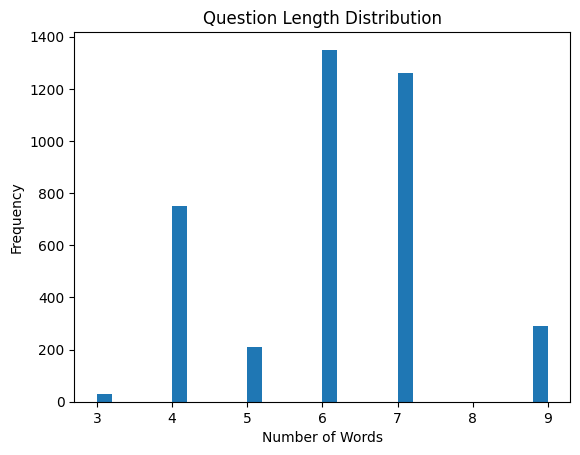

In [8]:
plt.hist(question_lengths, bins=30)
plt.title("Question Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

In [9]:
# Answer Length Distribution

all_answers = []

for df in qa_data:
    all_answers.extend(df["answer"].tolist())

answer_lengths = [len(a.split()) for a in all_answers]

print("Average answer length:", sum(answer_lengths)/len(answer_lengths))

Average answer length: 4.9406169665809765


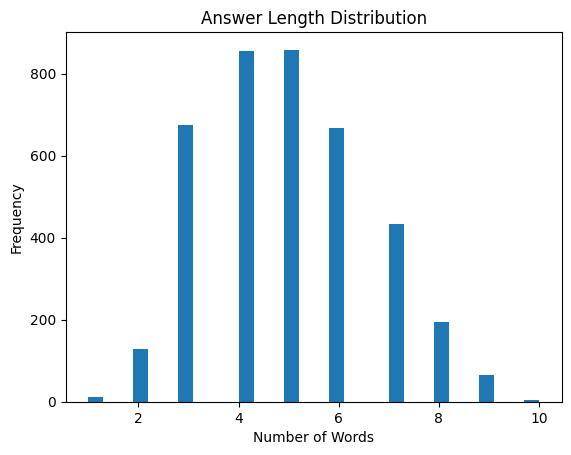

In [10]:
plt.hist(answer_lengths, bins=30)
plt.title("Answer Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

In [11]:
import arabic_reshaper
from bidi.algorithm import get_display

In [12]:
# Transcript Word Frequency Analysis
from collections import Counter

all_text = " ".join(transcripts)

tokens = all_text.split()

word_counts = Counter(tokens)

print(word_counts.most_common(20))

[('في', 1995), ('يا', 1806), ('عزيزي،', 1313), ('من', 1292), ('اللي', 1276), ('ما', 1135), ('إن', 916), ('على', 885), ('كان', 619), ('دا', 472), ('مش', 469), ('هو', 429), ('كل', 413), ('عشان', 365), ('زي', 341), ('دي', 338), ('انت', 296), ('بس', 263), ('كانت', 261), ('كدا،', 250)]


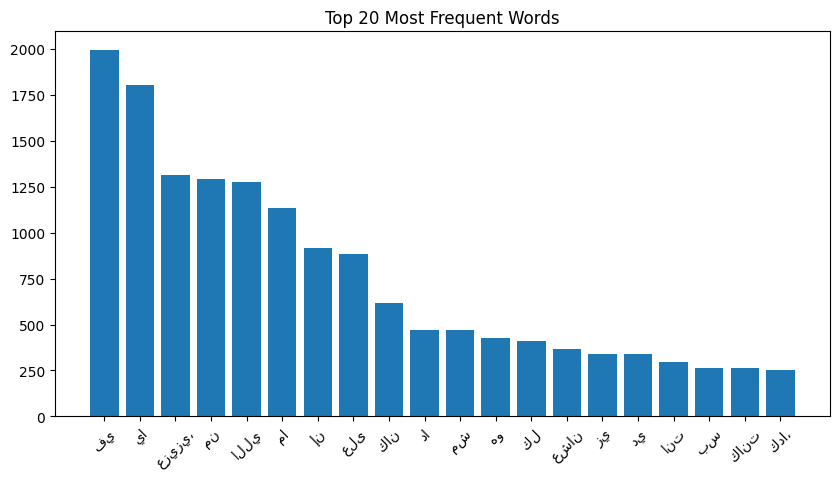

In [13]:
# Plotting Top Words
top_words = word_counts.most_common(20)

words = [w[0] for w in top_words]
counts = [w[1] for w in top_words]

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.title("Top 20 Most Frequent Words")
plt.xticks(rotation=45)
plt.show()

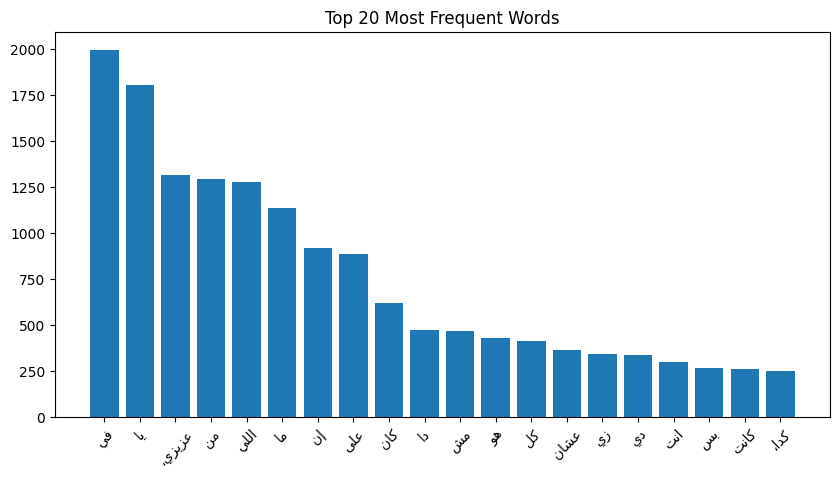

In [14]:
top_words = word_counts.most_common(20)

words = [get_display(arabic_reshaper.reshape(w[0])) for w in top_words]
counts = [w[1] for w in top_words]

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.title("Top 20 Most Frequent Words")
plt.xticks(rotation=45)
plt.show()

In [15]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.util import bigrams
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

nltk.download('punkt')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\maria\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [16]:
# wordcloud = WordCloud(
#     width=800,
#     height=400,
#     background_color="white"
# ).generate_from_frequencies(word_counts)

# plt.figure(figsize=(10,5))
# plt.imshow(wordcloud, interpolation="bilinear")
# plt.axis("off")
# plt.title("Word Cloud of Transcript Terms")
# plt.show()


In [17]:
# Transcript Length Distribution
transcript_lengths = [len(t.split()) for t in transcripts]

print("Average transcript length:", sum(transcript_lengths)/len(transcript_lengths))

Average transcript length: 6875.2307692307695


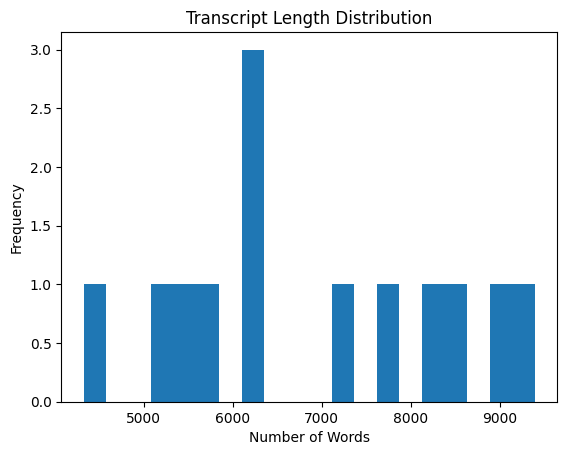

In [18]:
plt.hist(transcript_lengths, bins=20)
plt.title("Transcript Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

In [19]:
# Code-Switching Detection
import re

english_words = []

for t in transcripts:
    words = re.findall(r'[A-Za-z]+', t)
    english_words.extend(words)

print("Example English words detected:")
print(set(english_words))

Example English words detected:
{'area', 'information', 'Takeaway', 'Streltsy', 'Technology', 'position', 'Silverplate', 'Pictures', 'Giving', 'Macbeth', 'Superhero', 'Empathy', 'games', 'Ocean', 'Ex', 'angle', 'before', 'Puzzle', 'Carpet', 'cuts', 'only', 'Lion', 'Time', 'Folder', 'liberty', 'Terrible', 'All', 'PR', 'Multi', 'Crunch', 'Already', 'Advantage', 'obsession', 'N', 'Cross', 'direct', 'effects', 'Memento', 'and', 'Mank', 'aliens', 'blurred', 'accelerate', 'Software', 'entertainer', 'RAM', 'Animation', 'discovered', 'Jet', 'Title', 'Standard', 'Limit', 'Mix', 'Texture', 'Black', 'Package', 'VBB', 'Gases', 'Action', 'Sorry', 'Proxy', 'Miloslavskys', 'right', 'High', 'Cyber', 'Calories', 'Law', 'Sensors', 'at', 'natural', 'Recognition', 'campaign', 'Mall', 'in', 'Molluscan', 'Kane', 'Pixels', 'by', 'To', 'bombingham', 'Behavior', 'Vs', 'Suckers', 'Consciousness', 'beginning', 'Tape', 'Entrop', 'somewhere', 'Wolfi', 'Maverick', 'Palace', 'Dots', 'Ivan', 'Shake', 'Cognitive', 'Su

In [20]:
import re
from collections import Counter

english_words = []

for t in transcripts:
    # words = re.findall(r'[A-Za-z]+', t)
    words = re.findall(r'[A-Za-z]{3,}', t)
    english_words.extend(words)

print("Total English tokens:", len(english_words))

unique_english = set(english_words)
print("Unique English words:", len(unique_english))

english_counts = Counter(english_words)

print("Most common English words:")
print(english_counts.most_common(10))

Total English tokens: 971
Unique English words: 621
Most common English words:
[('The', 21), ('cult', 20), ('Kane', 15), ('Citizen', 14), ('Streltsy', 13), ('Actually', 12), ('Seppuku', 10), ('actually', 9), ('FBI', 9), ('Entropy', 8)]


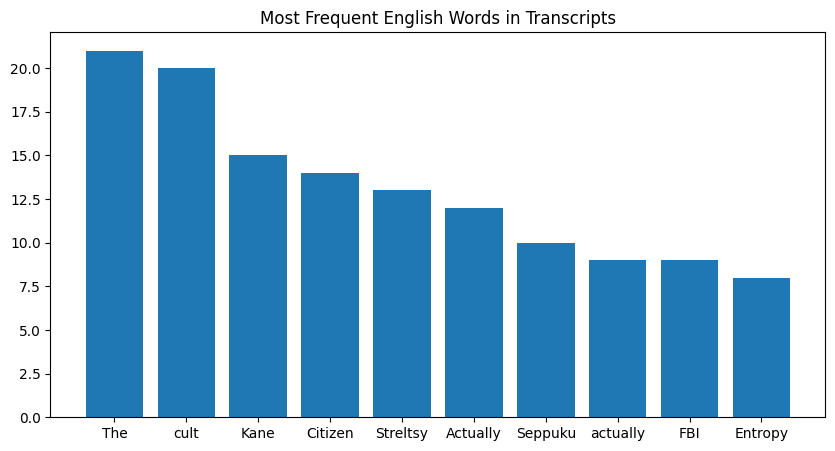

In [21]:
top_eng = english_counts.most_common(10)

words = [w[0] for w in top_eng]
counts = [w[1] for w in top_eng]

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.title("Most Frequent English Words in Transcripts")
plt.show()

In [22]:
# TF-IDF Keyword Analysis
from sklearn.feature_extraction.text import TfidfVectorizer

# vectorizer = TfidfVectorizer()

from sklearn.feature_extraction.text import TfidfVectorizer

arabic_stopwords = [
"في","من","على","ما","يا","اللي","هو","هي","كان","كانت","دا","دي","مش"
]

vectorizer = TfidfVectorizer(stop_words=arabic_stopwords)

tfidf_matrix = vectorizer.fit_transform(transcripts)

feature_names = vectorizer.get_feature_names_out()

print("Number of documents:", tfidf_matrix.shape[0])
print("Vocabulary size:", tfidf_matrix.shape[1])

Number of documents: 13
Vocabulary size: 22176


In [23]:
import numpy as np

first_doc = tfidf_matrix[0].toarray()[0]

top_indices = np.argsort(first_doc)[-10:]

for i in top_indices:
    print(feature_names[i])

كدا
الطيار
الطيارات
الرادار
35
إن
طيارة
الطيارة
الـf
عزيزي


This prints top TF-IDF words for transcript 1.

These should represent the topic of the episode.

In [24]:
import numpy as np

doc_index = 0

doc_vector = tfidf_matrix[doc_index].toarray()[0]

top_indices = np.argsort(doc_vector)[-10:]

for i in top_indices:
    print(feature_names[i])

كدا
الطيار
الطيارات
الرادار
35
إن
طيارة
الطيارة
الـf
عزيزي


In [25]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.util import bigrams
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

nltk.download('punkt')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\maria\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

Noise Detection and Normalization

In [26]:
import re

timestamps = []

for t in transcripts:
    found = re.findall(r"\d+\.\d+:", t)
    timestamps.extend(found)

print("Number of timestamps detected:", len(timestamps))
print("Example timestamps:", timestamps[:10])

Number of timestamps detected: 11109
Example timestamps: ['0.0:', '3.076:', '4.238:', '6.184:', '8.308:', '9.435:', '12.205:', '15.218:', '17.977:', '22.165:']


In [31]:
# Combine all transcripts into one string
all_text = " ".join(transcripts)

# ------------------------------
# 1️⃣ Timestamps
# ------------------------------
timestamps = re.findall(r"\d+\.\d+:", all_text)
print("Number of timestamps detected:", len(timestamps))
print("Example timestamps:", timestamps[:10])

# ------------------------------
# 2️⃣ Punctuation
# ------------------------------
punctuation = re.findall(r"[!?,.;:\"()\-\[\]؟!]", all_text)
print("Total punctuation symbols detected:", len(punctuation))
print("Example punctuation:", punctuation[:20])

# ------------------------------
# 3️⃣ Diacritics (Tashkeel)
# ------------------------------
diacritics = re.findall(r"[ًٌٍَُِّْ]", all_text)
print("Number of diacritics detected:", len(diacritics))
print("Example diacritics:", diacritics[:20])

# ------------------------------
# 4️⃣ Alef variants
# ------------------------------
alef_variants = re.findall(r"[إأآ]", all_text)
print("Number of Alef variants detected:", len(alef_variants))
print("Example Alef variants:", alef_variants[:20])

# ------------------------------
# 5️⃣ Ya variants (ى)
# ------------------------------
ya_variants = re.findall(r"ى", all_text)
print("Number of ى (Ya variants) detected:", len(ya_variants))
print("Example Ya variants:", ya_variants[:20])

# ------------------------------
# 6️⃣ Ta Marbuta (ة)
# ------------------------------
ta_marbuta = re.findall(r"ة", all_text)
print("Number of Ta Marbuta detected:", len(ta_marbuta))
print("Example Ta Marbuta:", ta_marbuta[:20])

# ------------------------------
# 7️⃣ Waw & Hamza variants (ؤ, ئ)
# ------------------------------
waw_hamza = re.findall(r"[ؤئ]", all_text)
print("Number of Waw/Hamza variants detected:", len(waw_hamza))
print("Example Waw/Hamza variants:", waw_hamza[:20])

# ------------------------------
# 8️⃣ Tatweel / Kashida (ـ)
# ------------------------------
tatweel = re.findall(r"ـ", all_text)
print("Number of Tatweel characters detected:", len(tatweel))
print("Example Tatweel:", tatweel[:10])

# ------------------------------
#  Special characters (anything non-text)
# ------------------------------
special_chars = re.findall(r"[^\u0600-\u06FFa-zA-Z0-9\s]", all_text)
print("Number of special characters detected:", len(special_chars))
print("Example special characters:", special_chars[:20])


Number of timestamps detected: 11109
Example timestamps: ['0.0:', '3.076:', '4.238:', '6.184:', '8.308:', '9.435:', '12.205:', '15.218:', '17.977:', '22.165:']
Total punctuation symbols detected: 33971
Example punctuation: ['.', ':', '.', ':', '.', ':', '"', '"', '.', '.', ':', '.', ':', '!', '.', ':', '.', ':', '-', '.']
Number of diacritics detected: 5568
Example diacritics: ['ً', 'ّ', 'ً', 'ً', 'ً', 'ً', 'ً', 'ً', 'ً', 'ّ', 'ُ', 'ّ', 'ُ', 'ً', 'ّ', 'ّ', 'َ', 'َ', 'ّ', 'ُ']
Number of Alef variants detected: 7900
Example Alef variants: ['أ', 'أ', 'أ', 'أ', 'أ', 'آ', 'إ', 'أ', 'أ', 'أ', 'إ', 'إ', 'إ', 'أ', 'إ', 'إ', 'إ', 'أ', 'أ', 'أ']
Number of ى (Ya variants) detected: 2185
Example Ya variants: ['ى', 'ى', 'ى', 'ى', 'ى', 'ى', 'ى', 'ى', 'ى', 'ى', 'ى', 'ى', 'ى', 'ى', 'ى', 'ى', 'ى', 'ى', 'ى', 'ى']
Number of Ta Marbuta detected: 7701
Example Ta Marbuta: ['ة', 'ة', 'ة', 'ة', 'ة', 'ة', 'ة', 'ة', 'ة', 'ة', 'ة', 'ة', 'ة', 'ة', 'ة', 'ة', 'ة', 'ة', 'ة', 'ة']
Number of Waw/Hamza variants detecte

In [33]:
from pathlib import Path
import sys

project_root = Path.cwd().resolve()
if not (project_root / "src").exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.normalization import normalize_arabic

clean_transcripts = [normalize_arabic(t) for t in transcripts]

# Example before/after
for i in range(3):
    print("Before:", transcripts[i][:100])
    print("After :", clean_transcripts[i][:100])
    print("-" * 50)

Before: 0.0: سيادة الكولونيل، صبرك في محله،
3.076: مبروك علينا،
4.238: عملنا أفجر طيارة في تاريخ "أمريكا".
6
After : سياده الكولونيل، صبرك في محله، مبروك علينا، عملنا افجر طياره في تاريخ امريكا انا متحمس جدا من امبارح
--------------------------------------------------
Before: 6.45: يا ربي!
7.756: أنا زهقت!
8.396: ما تثبت يا ابني بقى،
9.564: اثبت، تعبتني!
10.846: سيب الجهاز ي
After : يا ربي انا زهقت ما تثبت يا ابني بقي، اثبت، تعبتني سيب الجهاز يقرا بصراحه، انا مش عاجبني موضوع التجرب
--------------------------------------------------
Before: 0.167: منذ زمنٍ بعيد،
2.6: في أرضٍ ليست ببعيدة...
6.818: كان هُناك طفلٌ مصريٌ سمين،
10.204: يحلم بأن
After : منذ زمن بعيد، في ارض ليست ببعيده كان هناك طفل مصري سمين، يحلم بان يكون اول ساموراي مصري في العالم كب
--------------------------------------------------


In [37]:
import importlib
import src.normalization as normalization

importlib.reload(normalization)
remove_horof_el_jar = normalization.remove_horof_el_jar

clean_no_prepositions = [remove_horof_el_jar(t) for t in clean_transcripts]

# Show before/after
for i in range(3):
    print("Before:", clean_transcripts[i][:100])
    print("After :", clean_no_prepositions[i][:100])
    print("-" * 50)

Before: سياده الكولونيل، صبرك في محله، مبروك علينا، عملنا افجر طياره في تاريخ امريكا انا متحمس جدا من امبارح
After : سياده الكولونيل، صبرك محله، مبروك علينا، عملنا افجر طياره تاريخ امريكا انا متحمس جدا امبارح، ها، وري
--------------------------------------------------
Before: يا ربي انا زهقت ما تثبت يا ابني بقي، اثبت، تعبتني سيب الجهاز يقرا بصراحه، انا مش عاجبني موضوع التجرب
After : يا ربي انا زهقت ما تثبت يا ابني قي، اثبت، تعبتني سيب الجهاز يقرا صراحه، انا مش عاجبني موضوع التجربه 
--------------------------------------------------
Before: منذ زمن بعيد، في ارض ليست ببعيده كان هناك طفل مصري سمين، يحلم بان يكون اول ساموراي مصري في العالم كب
After : منذ زمن عيد، ارض يست بعيده ان هناك طفل مصري سمين، يحلم ان يكون اول ساموراي مصري العالم بر الطفل، وسا
--------------------------------------------------


In [38]:
def detect_foreign_words(text):
    return re.findall(r'[A-Za-z]{3,}', text)

egyptian_dialect = ["مش", "كده", "كدا", "إيه", "أيوة", "عايز", "هوه", "دي", "دا", "ليه", "ماشي"]

def detect_dialect_words(text):
    return [word for word in text.split() if word in egyptian_dialect]

foreign_tokens = [detect_foreign_words(t) for t in transcripts]
dialect_tokens = [detect_dialect_words(t) for t in transcripts]

all_foreign = [w for sublist in foreign_tokens for w in sublist]
all_dialect = [w for sublist in dialect_tokens for w in sublist]

print("Most common foreign words:", Counter(all_foreign).most_common(10))
print("Most common dialect words:", Counter(all_dialect).most_common(10))

Most common foreign words: [('The', 21), ('cult', 20), ('Kane', 15), ('Citizen', 14), ('Streltsy', 13), ('Actually', 12), ('Seppuku', 10), ('actually', 9), ('FBI', 9), ('Entropy', 8)]
Most common dialect words: [('دا', 472), ('مش', 469), ('دي', 338), ('كدا', 101), ('إيه', 99), ('عايز', 72), ('ليه', 49), ('كده', 36), ('ماشي', 25), ('أيوة', 1)]


In [40]:
from collections import defaultdict

# Tokenize all text
tokens = all_text.split()

# Normalize words for detection only
def normalize_for_detection(word):
    word = re.sub(r"[ًٌٍَُِّْ]", "", word)      # diacritics
    word = re.sub(r"[إأآ]", "ا", word)           # alef
    word = re.sub(r"ى", "ي", word)               # ya
    word = re.sub(r"ة", "ه", word)               # ta marbuta
    word = re.sub(r"[ؤ]", "و", word)             # waw hamza
    word = re.sub(r"[ئ]", "ي", word)             # hamza ya
    word = re.sub(r"(.)\1{2,}", r"\1", word)     # repeated letters
    return word

groups = defaultdict(list)
for word in tokens:
    norm = normalize_for_detection(word)
    groups[norm].append(word)

# Show words with multiple forms
for norm_word, variations in groups.items():
    unique_variations = set(variations)
    if len(unique_variations) > 1:
        print(f"Normalized: {norm_word} -> Variations: {unique_variations}")

Normalized: انا -> Variations: {'أنا', 'إنا', 'انا'}
Normalized: جدا -> Variations: {'جدًا', 'جدا'}
Normalized: من -> Variations: {'مَن', 'من'}
Normalized: شبه -> Variations: {'شِبه', 'شَبَه', 'شبه'}
Normalized: اه، -> Variations: {'أه،', 'آه،'}
Normalized: ايه -> Variations: {'إيه', 'ايه'}
Normalized: كدا. -> Variations: {'كدا.', 'كدا...'}
Normalized: حته -> Variations: {'حته', 'حتة'}
Normalized: تقريبا -> Variations: {'تقريبًا', 'تقريبا'}
Normalized: طفل -> Variations: {'طفل', 'طفلٌ'}
Normalized: بصراحه. -> Variations: {'بصراحة...', 'بصراحة.'}
Normalized: علي -> Variations: {'على', 'عِلي', 'علي'}
Normalized: فيه -> Variations: {'فيه', 'فئه', 'فئة'}
Normalized: يعني. -> Variations: {'يعني.', 'يعني...'}
Normalized: طب -> Variations: {'طِب', 'طب'}
Normalized: ان -> Variations: {'أن', 'ان', 'إن'}
Normalized: هناك -> Variations: {'هُناك', 'هناك'}
Normalized: مثلا -> Variations: {'مثلًا', 'مثلا'}
Normalized: يقدر -> Variations: {'يقدر', 'يُقدّر'}
Normalized: انت -> Variations: {'أنت', 'انت

Cleaning is necessary because:
- Different spellings of the same word are treated as different tokens.
- Timestamps, punctuation, and special characters interfere with tokenization.
- Removing irrelevant prepositions simplifies the vocabulary.
- Dialectal and foreign words may not align with embeddings, reducing model performance.
- Normalization reduces vocabulary size, improves generalization.

In [39]:
all_words_before = len(set(all_text.split()))
all_words_after = len(set(" ".join(clean_no_prepositions).split()))
print("Unique words before cleaning:", all_words_before)
print("Unique words after cleaning :", all_words_after)

Unique words before cleaning: 36776
Unique words after cleaning : 20963
